In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA


## Análisis de predicción de ESTACIONES para distintos escenarios. 

In [2]:
# Cargar datos
dftarifa=pd.read_csv("dftarifa.csv", encoding='latin1')

In [3]:
dftarifa.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,...,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA,cluster,FECHA_DATETIME,TARIFA,MES
5077213,2014-02-21,21:00:00,21:14:00,D,LINEA_D_CONGRESOTUC_S_TURN03,CONGRESO DE TUCUMAN,15,1,2,15,...,2,221,31,20140221,2100,2114,2,2014-02-21,3.5,2
3898565,2014-05-25,17:45:00,17:59:00,D,LINEA_D_CATEDRAL_O_TURN05,CATEDRAL,23,1,1,24,...,2,287,26,20140525,1745,1759,2,2014-05-25,4.5,5
1440351,2014-05-12,16:30:00,16:44:00,C,LINEA_C_LAVALLE_S_TURN02,LAVALLE,49,1,1,50,...,1,161,21,20140512,1630,1644,6,2014-05-12,4.5,5
6216173,2014-11-08,14:00:00,14:14:00,E,LINEA_E_BOEDO_TURN03,BOEDO,10,0,0,10,...,3,344,45,20141108,1400,1414,7,2014-11-08,4.5,11
3959362,2014-07-31,14:15:00,14:29:00,H,LINEA_H_CASEROS_NORTE_TURN01,CASEROS,22,1,1,23,...,4,400,57,20140731,1415,1429,7,2014-07-31,4.5,7


In [4]:
dftarifa.columns

Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ESTACION', 'PAX_PAGO',
       'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL', 'TOTAL', 'LINEA_NUMERICA',
       'MOLINETE_NUMERICO', 'ESTACION_NUMERICA', 'FECHA_NUMERICA',
       'DESDE_NUMERICA', 'HASTA_NUMERICA', 'cluster', 'FECHA_DATETIME',
       'TARIFA', 'MES'],
      dtype='object')

**¿Qué estaciones experimentan cambios significativos en el flujo de pasajeros en función del día y hora?**

**# Seleccionar estación de interés**

- El siguiente código filtra un DataFrame "dftarifa" para analizar los datos correspondientes a una estación específica del subte.

- Explicación:
1. estacion = 'CARLOS GARDEL': se define el nombre de la estación a analizar.
2. se crea un nuevo DataFrame (df_estacion) que contiene solo los registros donde la columna 'ESTACION' coincide con el nombre ingresado.

- Uso: permite enfocar el análisis (por ejemplo, visualización, estadísticas o predicciones) exclusivamente sobre una estación determinada.

In [5]:
# Ingresar el nombre de la estación que se desea analizar.

estacion = 'CARLOS GARDEL'
df_estacion = dftarifa[dftarifa['ESTACION'] == estacion]

- El siguiente código realiza una descomposición de serie temporal sobre los datos de la estación seleccionada, aplicando un modelo aditivo.

- Explicación:
1. df_estacion['TOTAL']: es la serie temporal que se desea descomponer (por ejemplo, cantidad total de pasajeros en una estación a lo largo del tiempo).
2. seasonal_decompose(..., model='additive', period=12): aplica un modelo aditivo, donde
serie = tendencia + estacionalidad + ruido.

- El parámetro period=12 indica que se espera una estacionalidad cada 12 períodos (por ejemplo, si los datos son mensuales, corresponde a un ciclo anual).
- decomposicion: es un objeto que contiene los tres componentes separados: tendencia, estacionalidad y residuo (ruido).

- Objetivo: entender mejor la evolución temporal de la demanda en una estación determinada, identificando patrones regulares y variaciones a largo plazo.

In [6]:
# Descompongo la serie temporal en tendencia, estacionalidad y ruido
decomposicion = seasonal_decompose(df_estacion['TOTAL'], model='additive', period=12)

- En el siguiente codigo,se extrae y almacena los tres componentes resultantes de la descomposición de la serie temporal:
1. tendencia = decomposicion.trend: representa el comportamiento a largo plazo o dirección general de la serie (por ejemplo, si la demanda aumenta o disminuye con el tiempo).
2. estacionalidad = decomposicion.seasonal: captura los patrones cíclicos repetitivos dentro del período definido (como picos mensuales, estacionales, etc.).
3. ruido = decomposicion.resid: muestra las irregularidades o variaciones no explicadas por la tendencia ni la estacionalidad (comportamiento aleatorio o errores).

- Estas variables permiten visualizar por separado los distintos factores que influyen en la evolución de la demanda en la estación analizada.

In [7]:
# Visualizo descomposición
tendencia = decomposicion.trend
estacionalidad = decomposicion.seasonal
ruido = decomposicion.resid

**Visualizacion Grafica de los resultados**

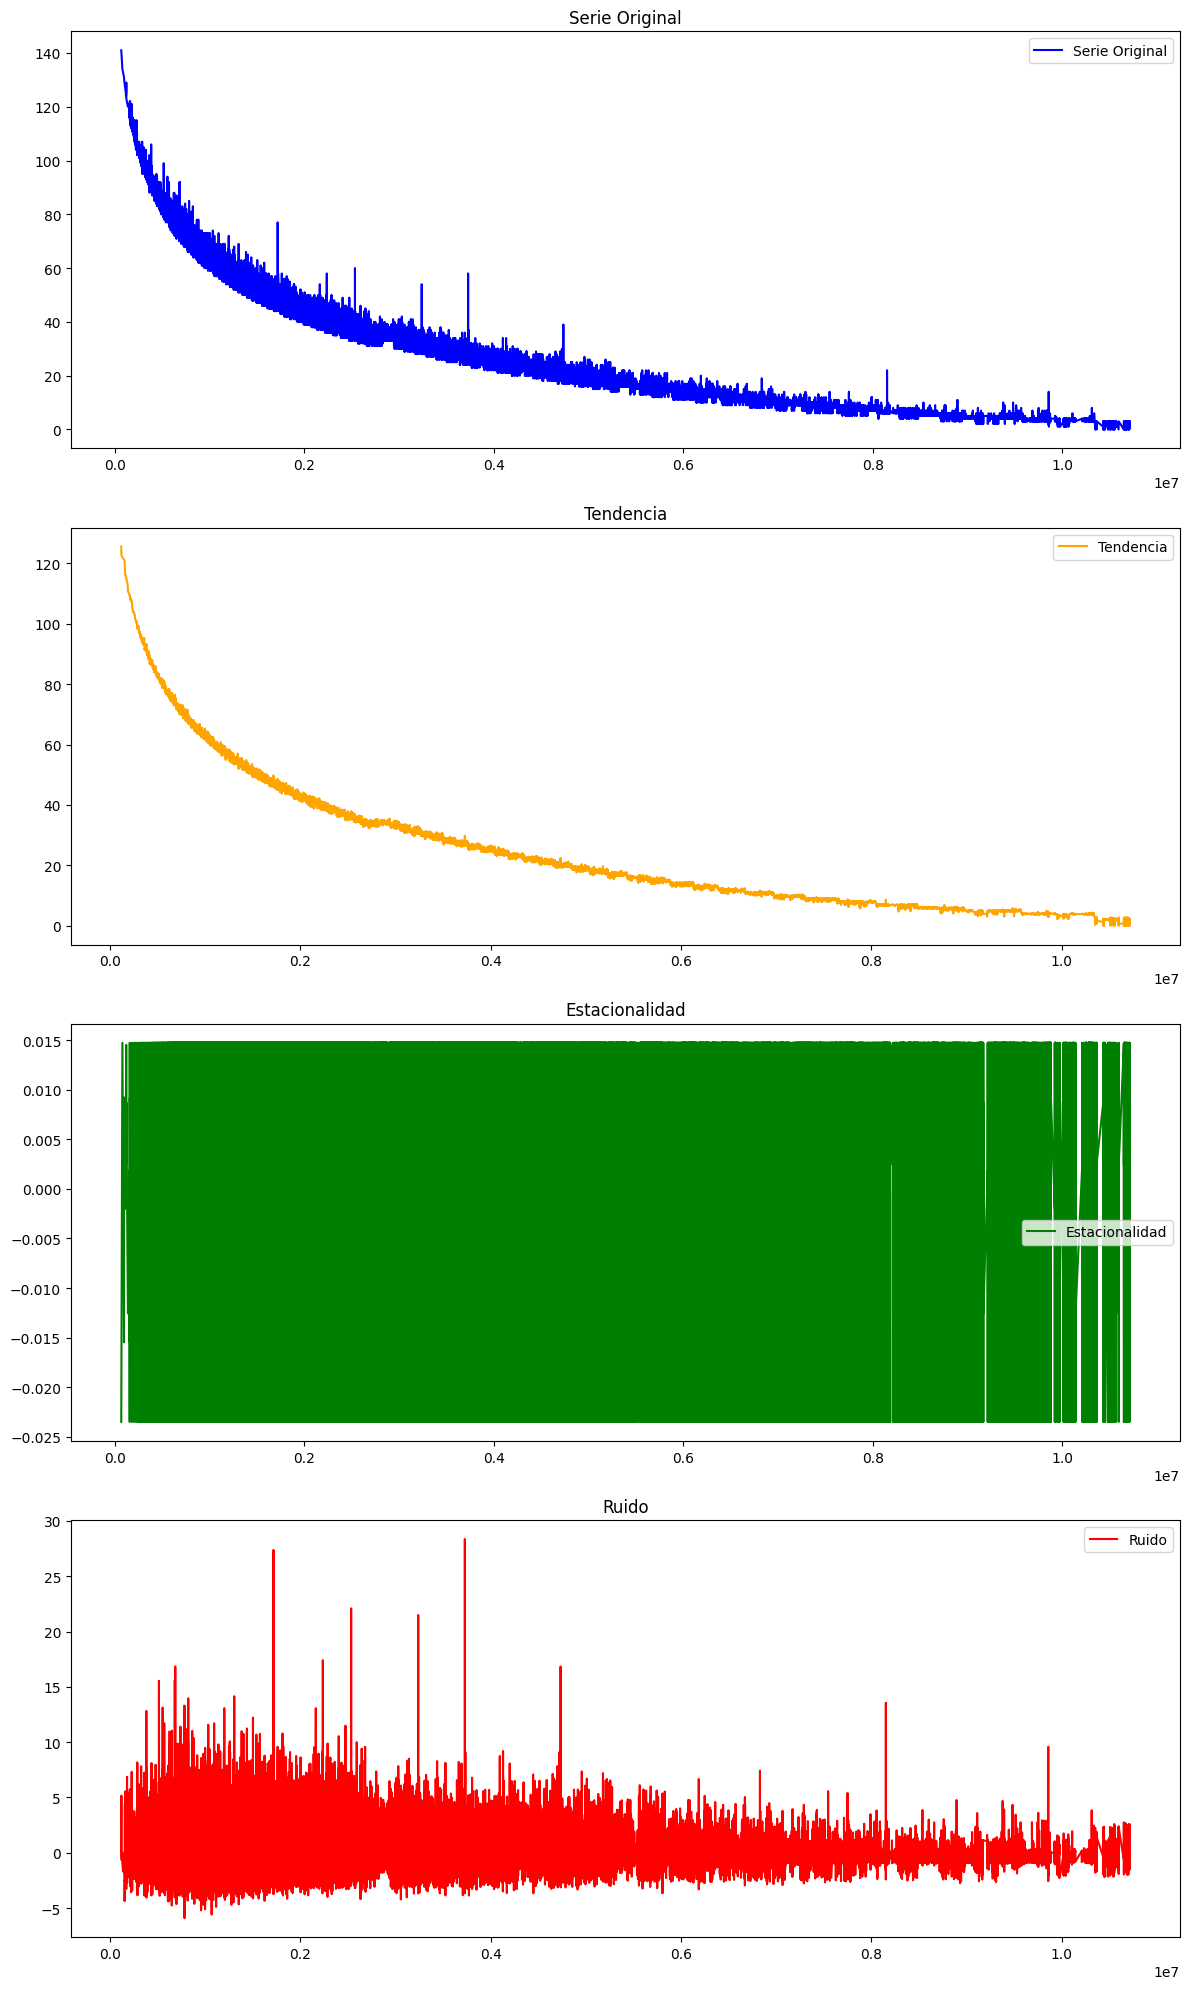

In [8]:
plt.figure(figsize=(12, 20))

# Serie original

plt.subplot(411)
plt.plot(df_estacion['TOTAL'], label='Serie Original', color='blue')
plt.title('Serie Original')
legend = plt.legend(loc='best')
for text in legend.get_texts():
    text.set_color("black")



# Tendencia
plt.subplot(412)
plt.plot(tendencia, label='Tendencia', color='orange')
plt.title('Tendencia')
legend = plt.legend(loc='best')
for text in legend.get_texts():
    text.set_color("black")


# Estacionalidad
plt.subplot(413)
plt.plot(estacionalidad, label='Estacionalidad', color='green')
plt.title('Estacionalidad')
legend = plt.legend(loc='best')
for text in legend.get_texts():
    text.set_color("black")


# Ruido
plt.subplot(414)
plt.plot(ruido, label='Ruido', color='red')
plt.title('Ruido')
legend = plt.legend(loc='best')
for text in legend.get_texts():
    text.set_color("black")


plt.tight_layout()
plt.show()

- Serie Original
1. Qué muestra: la evolución temporal de la cantidad total de pasajeros sin ningún procesamiento.
2. Interpretación: permite observar la estructura general de la serie, incluyendo posibles aumentos, disminuciones, estacionalidades y anomalías. Es el punto de partida para el análisis.



- Tendencia
1. Qué muestra: la evolución a largo plazo de la serie, suavizando las fluctuaciones de corto plazo.
2. Interpretación: refleja si el número de pasajeros ha ido creciendo, disminuyendo o permaneciendo estable a lo largo del tiempo. Es útil para identificar comportamientos estructurales.



- Estacionalidad
1. Qué muestra: los patrones repetitivos o cíclicos en intervalos regulares (por ejemplo, mensual o semanal).
2. Interpretación: indica si existen variaciones sistemáticas que se repiten en los mismos períodos, como picos de uso en ciertos meses o días. Esto es clave para planificación operativa y toma de decisiones.



- Ruido (Residuo)
1. Qué muestra: lo que queda de la serie original una vez eliminadas la tendencia y la estacionalidad.
2. Interpretación: representa fluctuaciones aleatorias o factores externos no modelados. Una alta variabilidad en el ruido puede sugerir la necesidad de incluir nuevas variables o que hay eventos impredecibles impactando la serie.


- A continuacion, se crea un modelo ARIMA para modelar y predecir la serie temporal de pasajeros en una estación específica. 

- El parámetro order=(1,1,1) indica que se aplica una diferenciación de primer orden para hacer la serie estacionaria, junto con un componente autorregresivo (AR) y uno de media móvil (MA), ambos de orden 1.
1. AR (Autoregressive): Es la parte autorregresiva del modelo. Utiliza una combinación lineal de los valores pasados de la serie para predecir el valor actual. Por ejemplo, si AR=1, el modelo usa el valor anterior para estimar el actual.
2. MA (Moving Average): Es la parte de media móvil. Modela el error (residuos) como una combinación lineal de errores pasados. Si MA=1, el modelo usa el error del paso anterior para corregir la predicción actual.

Ambos componentes ayudan a capturar patrones de dependencia en los datos de series temporales. 
- Finalmente, el modelo se ajusta a los datos reales con .fit().

In [9]:
# Creo el modelo ARIMA
modelo = ARIMA(df_estacion['TOTAL'], order=(1,1,1))
modelo_fit = modelo.fit()


/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


- El siguiente código visualiza por medio de un grafico, los residuos del modelo ARIMA, es decir, la diferencia entre los valores reales y los valores predichos por el modelo.
- Analizar esta gráfica permite evaluar si los residuos se comportan como ruido blanco (sin patrón), lo cual es una señal de que el modelo ha capturado adecuadamente la estructura de la serie temporal.
- Idealmente, los residuos deben oscilar alrededor de cero sin tendencia ni estacionalidad.

In [10]:
residuos = modelo_fit.resid

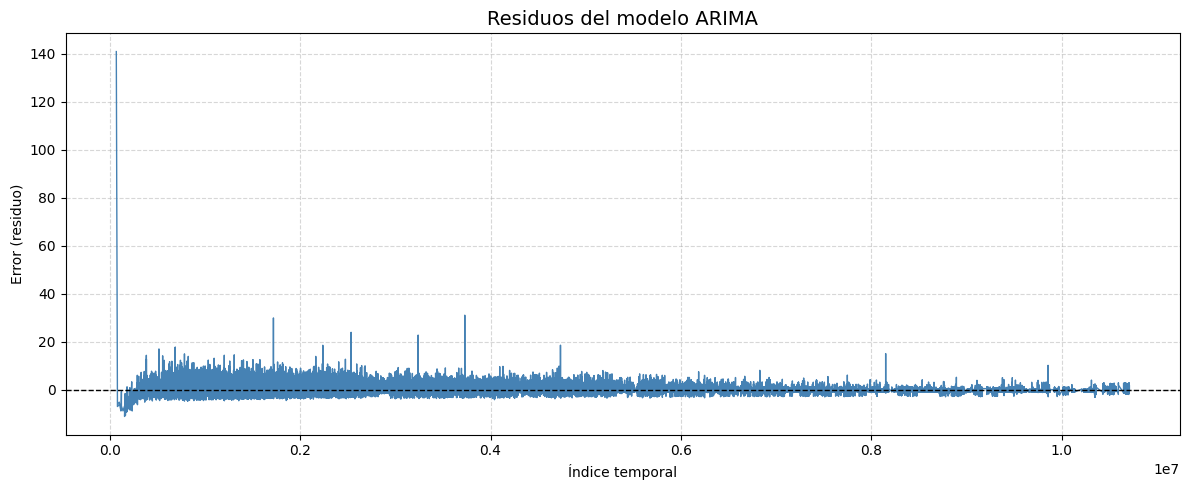

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(residuos, color='steelblue', linewidth=1)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residuos del modelo ARIMA', fontsize=14)
plt.xlabel('Índice temporal')
plt.ylabel('Error (residuo)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
#Ordeno el Dataframe df_estacion por fecha.
df_estacion = df_estacion.sort_values(by='FECHA_DATETIME')

In [13]:
df_estacion.head(10)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,...,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA,cluster,FECHA_DATETIME,TARIFA,MES
2525095,2014-01-02,11:30:00,11:44:00,B,LINEA_B_GARDEL_N_TURN03,CARLOS GARDEL,33,1,2,36,...,0,78,12,20140102,1130,1144,5,2014-01-02,3.5,1
2274443,2014-01-02,13:00:00,13:14:00,B,LINEA_B_GARDEL_N_TURN03,CARLOS GARDEL,36,1,1,37,...,0,78,12,20140102,1300,1314,5,2014-01-02,3.5,1
724889,2014-01-02,19:15:00,19:29:00,B,LINEA_B_GARDEL_N_TURN03,CARLOS GARDEL,68,1,2,68,...,0,78,12,20140102,1915,1929,6,2014-01-02,3.5,1
7010482,2014-01-02,07:15:00,07:29:00,B,LINEA_B_GARDEL_S_TURN03,CARLOS GARDEL,7,1,2,7,...,0,81,12,20140102,715,729,1,2014-01-02,3.5,1
7011372,2014-01-02,09:00:00,09:14:00,B,LINEA_B_GARDEL_S_TURN02,CARLOS GARDEL,7,1,2,7,...,0,80,12,20140102,900,914,1,2014-01-02,3.5,1
2267368,2014-01-02,20:15:00,20:29:00,B,LINEA_B_GARDEL_S_TURN03,CARLOS GARDEL,36,1,2,36,...,0,81,12,20140102,2015,2029,6,2014-01-02,3.5,1
2267193,2014-01-02,21:00:00,21:14:00,B,LINEA_B_GARDEL_S_TURN03,CARLOS GARDEL,36,1,2,36,...,0,81,12,20140102,2100,2114,6,2014-01-02,3.5,1
5122395,2014-01-02,07:30:00,07:44:00,B,LINEA_B_GARDEL_S_TURN01,CARLOS GARDEL,15,1,2,15,...,0,79,12,20140102,730,744,1,2014-01-02,3.5,1
7015532,2014-01-02,10:30:00,10:44:00,B,LINEA_B_GARDEL_S_TURN03,CARLOS GARDEL,7,1,2,7,...,0,81,12,20140102,1030,1044,1,2014-01-02,3.5,1
5123121,2014-01-02,09:45:00,09:59:00,B,LINEA_B_GARDEL_N_TURN03,CARLOS GARDEL,15,1,1,16,...,0,78,12,20140102,945,959,1,2014-01-02,3.5,1


In [14]:
#df_estacion.index = pd.to_datetime(df_estacion.index)

- El siguiente código realiza las predicciones retroactivas (out-of-sample) con el modelo ARIMA ya entrenado. 

- Se genera una predicción de los últimos 12 valores de la serie temporal, especificando el rango start y end en base al índice. 
- El parámetro typ='levels' indica que las predicciones se dan en valores reales (no diferenciados). Esto permite comparar directamente las predicciones con los datos originales.


In [15]:
# Realizo las predicciones
predicciones = modelo_fit.predict(start=len(df_estacion)-12, end=len(df_estacion)-1, typ='levels')

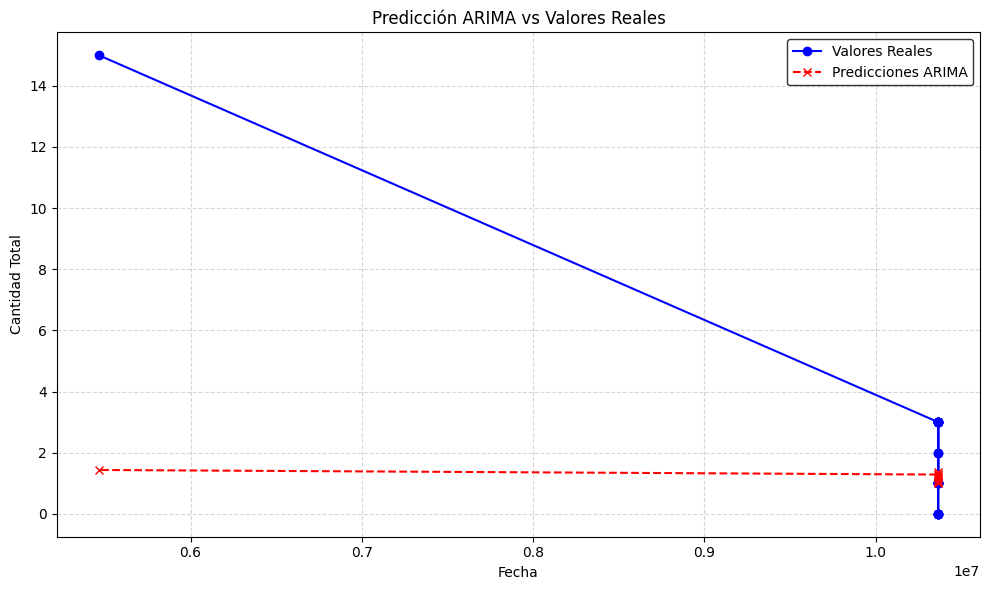

In [16]:
#Visualizo las predicciones por medio de un gráfico

plt.figure(figsize=(10,6))
plt.plot(df_estacion.index[-24:], df_estacion['TOTAL'][-24:], label='Valores Reales', color='blue', marker='o')
plt.plot(df_estacion.index[-12:], predicciones, label='Predicciones ARIMA', color='red', linestyle='--', marker='x')
plt.title('Predicción ARIMA vs Valores Reales')
plt.xlabel('Fecha')
plt.ylabel('Cantidad Total')
plt.legend(facecolor='white', edgecolor='black', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

1. Puntos azules (●): representan los valores reales observados en la estación que estás analizando (por ejemplo, “CARLOS GARDEL”). 
- Estos datos corresponden a la cantidad real de pasajeros en los últimos períodos (por ejemplo, meses o semanas, según tu serie).

2. Cruces rojas (×): representan las predicciones generadas por el modelo ARIMA. 
- Estas son estimaciones que el modelo hace basándose en el patrón histórico de la serie (tendencia, estacionalidad y ruido).

El objetivo es ver qué tan bien el modelo logra aproximarse a los valores reales. 
Si las cruces rojas están cerca de los puntos azules, el modelo tiene buen desempeño.

- El siguiente codigo, selecciona los datos de la estación "Carlos Gardel" (para este caso) y los organiza por fecha diaria, sumando el total de pasajeros por día. 
- Luego, convierte las fechas en un índice temporal y aplica un remuestreo para asegurar una frecuencia diaria uniforme. 
- Finalmente, realiza una descomposición estacional sobre la serie temporal para analizar sus componentes: tendencia, estacionalidad y residuo.

In [17]:
# Selecciono la estación de interés.
estacion = 'CARLOS GARDEL'
df_estacion = dftarifa.loc[dftarifa['ESTACION'] == estacion].copy()

# Convierto el índice a DatetimeIndex
df_estacion['FECHA_DATETIME'] = pd.to_datetime(df_estacion['FECHA'])
df_estacion.set_index('FECHA_DATETIME', inplace=True)

# Resamplear el DataFrame para obtener una frecuencia constante
df_estacion_resampleado = df_estacion['TOTAL'].resample('D').sum()

# Realizo la descomposición
decomposicion = seasonal_decompose(df_estacion_resampleado, model='additive')

- El siguiente código ajusta un modelo ARIMA (AutoRegressive Integrated Moving Average) a la serie temporal de pasajeros diarios en la estación Carlos Gardel.

- El orden (1,1,1) indica que se usa un componente autorregresivo de primer orden, una diferenciación para hacer la serie estacionaria, y un componente de media móvil también de primer orden.
- •	El primer número (1) es el componente autorregresivo (AR): el modelo usa el valor anterior de la serie para predecir el actual (es decir, se basa en los datos pasados).
- •	El segundo número (1) es la cantidad de diferenciaciones (I): resta el valor actual menos el anterior para eliminar tendencias y hacer la serie más estable (estacionaria).
- •	El tercer número (1) es el componente de media móvil (MA): corrige errores de predicción pasados combinando el residuo del paso anterior con el valor actual.

En resumen: el modelo ARIMA(1,1,1) usa la memoria del día anterior, ajusta por tendencias y corrige errores de predicción anteriores para hacer mejores estimaciones.
- Finalmente, el modelo es entrenado sobre los datos para captar patrones y realizar predicciones.

In [18]:
# Ajusto el modelo ARIMA
modelo = ARIMA(df_estacion_resampleado, order=(1,1,1))
modelo_fit = modelo.fit()


- El siguiente codigo, utiliza el modelo ARIMA ya entrenado para predecir el total diario de pasajeros en la estación Carlos Gardel entre el 1 y el 31 de enero de 2024.
- La función predict() genera valores estimados de la serie temporal en ese rango, basándose en los patrones aprendidos (tendencia, ciclos y errores pasados). 

In [19]:
# Realizo las predicciones
predicciones = modelo_fit.predict(start='2024-01-01', end='2024-01-31')

- El siguiente codigo, genera tres graficos para interpretar el modelo ARIMA aplicado:
	1.	Gráfico de descomposición: muestra la serie original separada en sus componentes:
	•	Tendencia: el cambio a largo plazo.
	•	Estacionalidad: patrones que se repiten (por día, semana, etc.).
	•	Ruido: variaciones no explicadas por los anteriores.
	2.	Gráfico de residuos: visualiza el error del modelo (diferencia entre valores reales y estimados). Sirve para verificar si el error es aleatorio o si quedan patrones sin modelar.
	3.	Gráfico de predicciones: compara los valores reales de enero de 2024 con las predicciones del modelo ARIMA, ayudando a evaluar su precisión.

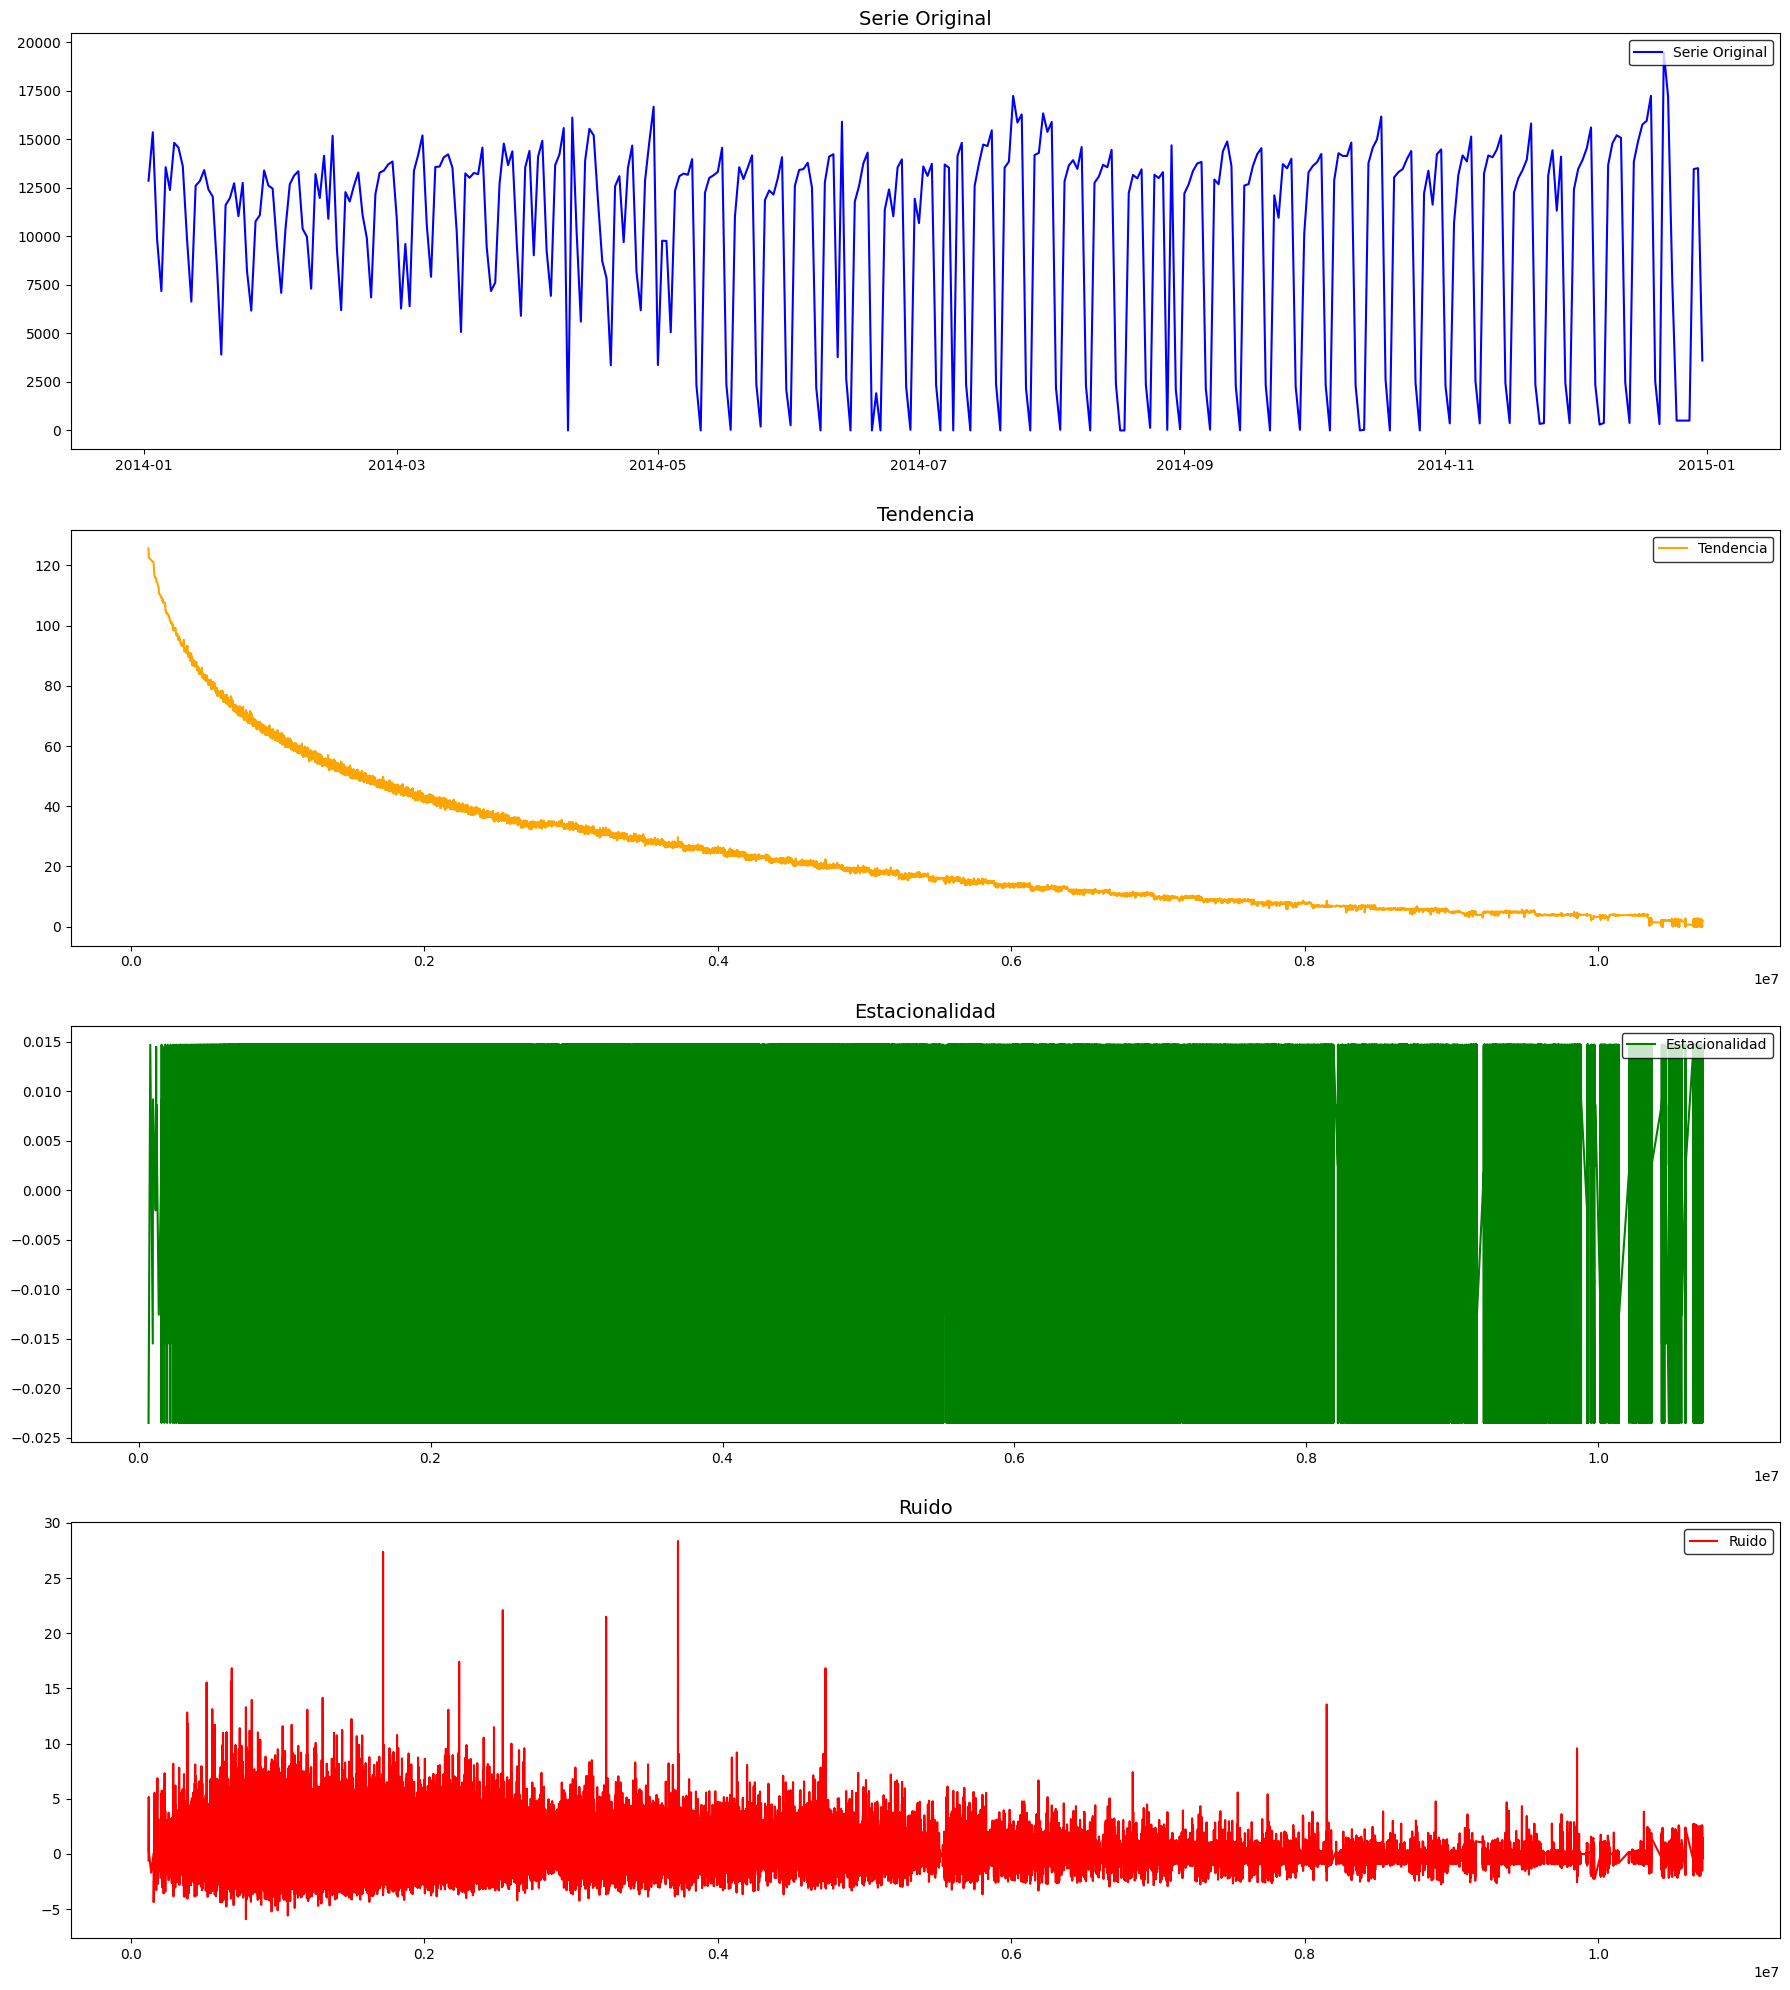

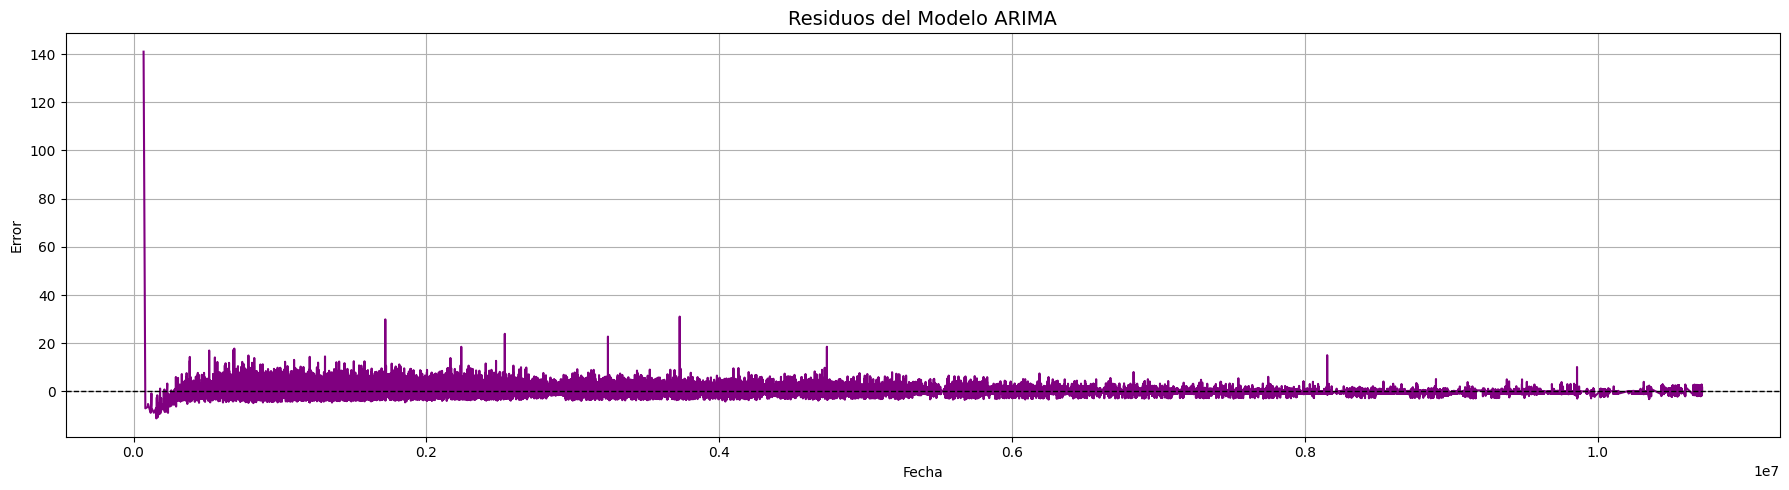

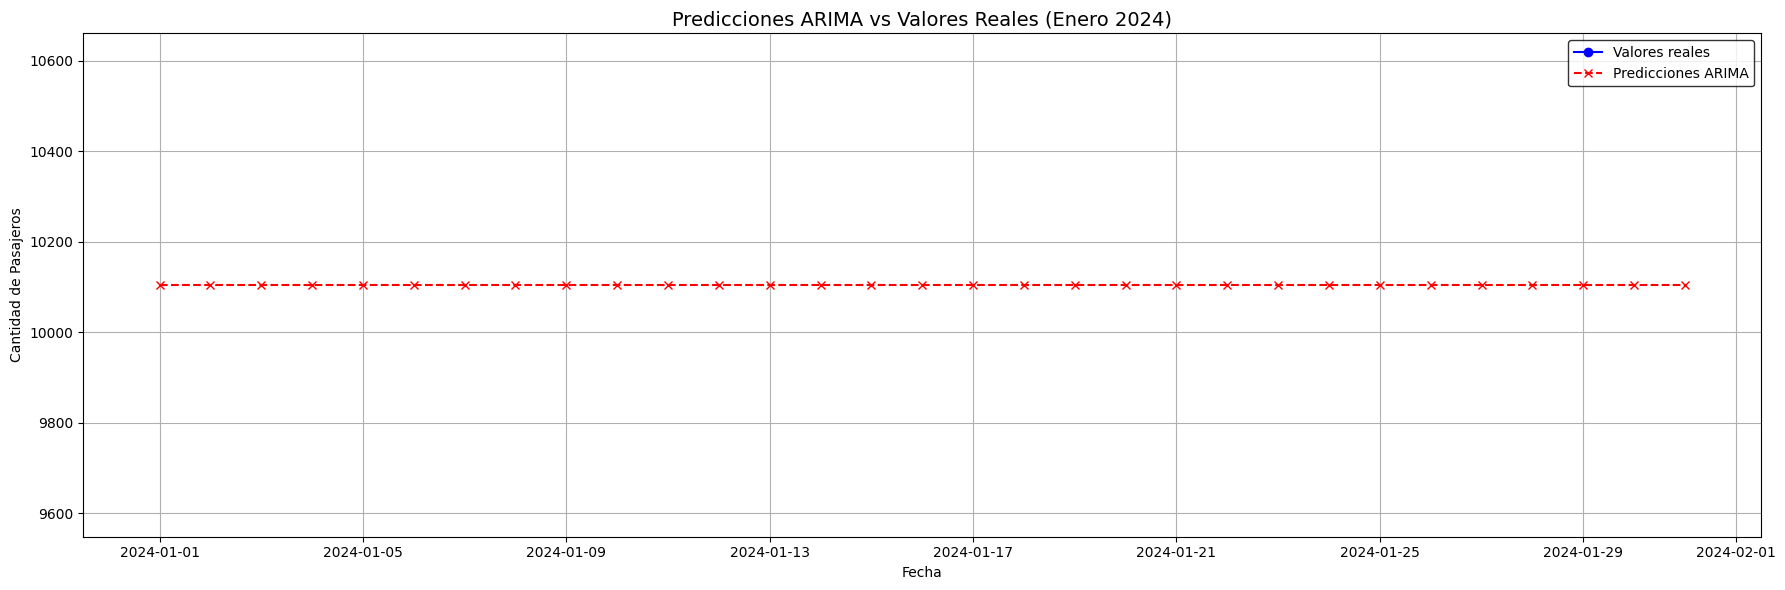

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. GRAFICO DE DESCOMPOSICIÓN
plt.figure(figsize=(18, 20))

plt.subplot(411)
plt.plot(df_estacion_resampleado, label='Serie Original', color='blue')
plt.title('Serie Original', fontsize=14)
plt.legend(loc='upper right', facecolor='white', edgecolor='black', labelcolor='black')

plt.subplot(412)
plt.plot(tendencia, label='Tendencia', color='orange')
plt.title('Tendencia', fontsize=14)
plt.legend(loc='upper right', facecolor='white', edgecolor='black', labelcolor='black')

plt.subplot(413)
plt.plot(estacionalidad, label='Estacionalidad', color='green')
plt.title('Estacionalidad', fontsize=14)
plt.legend(loc='upper right', facecolor='white', edgecolor='black', labelcolor='black')

plt.subplot(414)
plt.plot(ruido, label='Ruido', color='red')
plt.title('Ruido', fontsize=14)
plt.legend(loc='upper right', facecolor='white', edgecolor='black', labelcolor='black')

plt.tight_layout()
plt.show()

# 2. GRAFICO DE RESIDUOS 
plt.figure(figsize=(18, 5))
plt.plot(residuos, color='purple')
plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.title('Residuos del Modelo ARIMA', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Error')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. GRAFICO DE PREDICCIONES 
plt.figure(figsize=(18, 6))
plt.plot(df_estacion_resampleado['2024-01-01':'2024-01-31'], 
         label='Valores reales', marker='o', linestyle='-', color='blue')
plt.plot(predicciones, 
         label='Predicciones ARIMA', marker='x', linestyle='--', color='red')
plt.title('Predicciones ARIMA vs Valores Reales (Enero 2024)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(facecolor='white', edgecolor='black', labelcolor='black')
plt.grid(True)
plt.tight_layout()
plt.show()

**INTERPRETACION DE LOS GRAFICOS ANTERIORES**

1. Serie Original

Qué muestra:
La evolución diaria de la cantidad total de pasajeros en la estación Carlos Gardel.

Interpretación:
Este gráfico refleja el comportamiento real del tráfico de pasajeros a lo largo del tiempo. Podemos observar picos, caídas o patrones repetitivos que podrían corresponder a días laborables, fines de semana o eventos especiales.



2. Tendencia

Qué muestra:
La evolución general a largo plazo de la cantidad de pasajeros, eliminando variaciones estacionales y ruido.

Interpretación:
Este gráfico permite identificar si el uso de la estación está aumentando, disminuyendo o permaneciendo estable en el tiempo. Por ejemplo, una pendiente ascendente indica una creciente demanda de pasajeros.



3. Estacionalidad

Qué muestra:
Comportamientos cíclicos o patrones que se repiten a intervalos regulares (por ejemplo, semanal o mensual).

Interpretación:
Permite ver si hay días específicos con mayor o menor afluencia de pasajeros (por ejemplo, menor uso los fines de semana). Esta información es útil para ajustar horarios o personal operativo.



4. Ruido (Residuos de la Descomposición)

Qué muestra:
Variaciones no explicadas por la tendencia ni la estacionalidad.

Interpretación:
Estas irregularidades pueden deberse a eventos inesperados como interrupciones del servicio, feriados, clima extremo, etc. Un ruido muy disperso sugiere una serie con muchas fluctuaciones impredecibles.



5. Residuos del Modelo ARIMA

Qué muestra:
La diferencia entre las predicciones del modelo ARIMA y los valores reales observados.

Interpretación:
Idealmente, estos residuos deben oscilar alrededor de cero sin patrones visibles. Si se detectan tendencias o autocorrelaciones, significa que el modelo no está capturando completamente la dinámica de la serie.



6. Predicciones ARIMA vs Valores Reales

Qué muestra:
Comparación entre las predicciones realizadas por el modelo ARIMA y los datos reales para enero de 2024.

Interpretación:
Evalúa la capacidad del modelo para anticipar el comportamiento de la serie. Una buena coincidencia entre puntos azules (reales) y cruces rojas (predichos) indica un buen ajuste. Desvíos sistemáticos señalarían la necesidad de mejorar el modelo.


- Con el siguiente código, preparo y me aseguro que el formato del conjunto de los datos esten listos para el ultimo análisis sobre el comportamiento de los padajeros en las distintas Estaciones.

In [21]:
#Se convierte la columna FECHA a formato datetime y se filtran los registros cuyo año sea 2014. El resultado se almacena en un nuevo DataFrame llamado df_2014.
df_2014 = dftarifa[pd.to_datetime(dftarifa['FECHA']).dt.year == 2014]
#Se asegura que los valores en la columna TARIFA sean numéricos. Los valores no convertibles (por ejemplo, cadenas no numéricas) se reemplazan con NaN.
df_2014['TARIFA'] = pd.to_numeric(df_2014['TARIFA'], errors='coerce')
#Se eliminan las filas que contienen valores nulos en la columna TARIFA, asegurando que sólo se conserven registros con tarifas válidas.
df_2014 = df_2014.dropna(subset=['TARIFA'])
#Se añade una nueva columna MES que representa el mes (1 a 12) extraído de la fecha original.
df_2014['MES'] = pd.to_datetime(df_2014['FECHA']).dt.month
#Se incorpora una columna DIA_SEMANA, que indica el día de la semana (0 = lunes, 6 = domingo).
df_2014['DIA_SEMANA'] = pd.to_datetime(df_2014['FECHA']).dt.dayofweek
#Se genera una nueva columna HORA_DIA con la hora (0 a 23) correspondiente a cada registro, permitiendo análisis horarios.
df_2014['HORA_DIA'] = pd.to_datetime(df_2014['FECHA']).dt.hour

## ANALISIS DE ESTACIONES CON MAYOR VARIACION DE PASAJEROS.

- El siguiente código identifica las estaciones del subte con mayor fluctuación en el flujo de pasajeros a lo largo de la semana y del día, lo cual puede ser clave para optimizar recursos, planificar servicios o detectar patrones de comportamiento atípicos.
- Esto permite no solo saber qué estaciones son más variables, sino cuándo ocurre esa variación más extrema.

In [22]:

# Agrupo por estación, día de la semana y hora del día, y calculo el promedio
df_grupo = df_2014.groupby(['ESTACION', 'DIA_SEMANA', 'HORA_DIA'])['TOTAL'].mean().reset_index()

# Calculo la desviación estándar y promedio por estación
df_estadisticas = df_grupo.groupby('ESTACION').agg(
    VARIACION=('TOTAL', 'std'),
    PROMEDIO=('TOTAL', 'mean'),
    N_OBSERVACIONES=('TOTAL', 'count')
).reset_index()

# Combino estadísticos con el grupo original
df_completo = pd.merge(df_grupo, df_estadisticas, on='ESTACION')

# Calculo la diferencia absoluta respecto al promedio de la estación
df_completo['DIF_ABS'] = abs(df_completo['TOTAL'] - df_completo['PROMEDIO'])

# Para cada estación, identifico el día y la hora con mayor diferencia
df_max_desvio = df_completo.sort_values('DIF_ABS', ascending=False).groupby('ESTACION').first().reset_index()

# Selecciono y ordeno las 10 estaciones con mayor variación
df_top = df_max_desvio.sort_values(by='VARIACION', ascending=False).head(10)

# Redondeo para claridad
df_top['VARIACION'] = df_top['VARIACION'].round(2)
df_top['PROMEDIO'] = df_top['PROMEDIO'].round(2)
df_top['TOTAL'] = df_top['TOTAL'].round(2)

# Renombro columnas para claridad
df_top = df_top.rename(columns={
    'TOTAL': 'TOTAL_MAX_DESVIO',
    'DIA_SEMANA': 'DIA_MAX_DESVIO',
    'HORA_DIA': 'HORA_MAX_DESVIO'
})

# Mapeo de números de día a nombres
dias_semana = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}

# Aplicar mapeo
df_top['DIA_MAX_DESVIO'] = df_top['DIA_MAX_DESVIO'].map(dias_semana)

# Formatear la hora como texto con formato HH:00
df_top['HORA_MAX_DESVIO'] = df_top['HORA_MAX_DESVIO'].apply(lambda h: f"{int(h):02d}:00")

# Muestro el resultado
print(df_top[['ESTACION', 'VARIACION', 'PROMEDIO', 'TOTAL_MAX_DESVIO', 'DIA_MAX_DESVIO', 'HORA_MAX_DESVIO', 'N_OBSERVACIONES']])

             ESTACION  VARIACION  PROMEDIO  TOTAL_MAX_DESVIO DIA_MAX_DESVIO  \
43    LEANDRO N. ALEM      22.20     42.92              7.62        Domingo   
67        PUEYRREDON.      21.59     51.63             15.30        Domingo   
30            FLORIDA      19.51     37.26              5.89        Domingo   
10             CALLAO      17.79     36.58              7.26        Domingo   
47            MALABIA      15.90     34.08              7.43        Domingo   
80            URUGUAY      15.67     30.20              5.42        Domingo   
71              ROSAS      15.56     32.73              6.71        Domingo   
17           CATEDRAL      15.43     32.13              8.48        Domingo   
14  CARLOS PELLEGRINI      14.86     33.36              8.94        Domingo   
50            MEDRANO      14.61     33.09              8.44        Domingo   

   HORA_MAX_DESVIO  N_OBSERVACIONES  
43           00:00                7  
67           00:00                7  
30           00:

- En el siguiente codigo, lo grafico para poder observar que la mayor variacion se da los dias DOMINGOS.

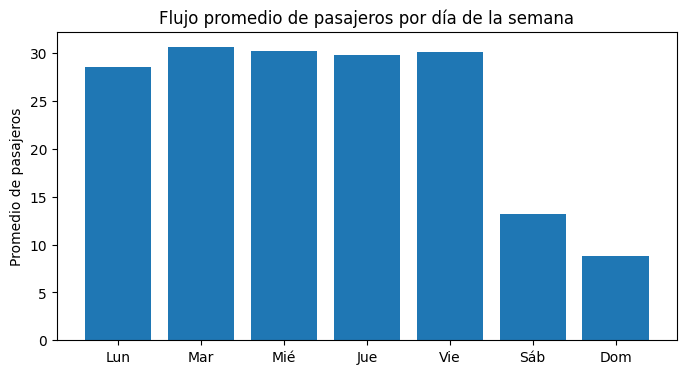

In [23]:
df_2014['DIA_SEMANA'] = pd.to_datetime(df_2014['FECHA']).dt.dayofweek
df_dia = df_2014.groupby('DIA_SEMANA')['TOTAL'].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(df_dia['DIA_SEMANA'], df_dia['TOTAL'])
plt.xticks(range(7), ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'])
plt.ylabel('Promedio de pasajeros')
plt.title('Flujo promedio de pasajeros por día de la semana')
plt.show()

- En el siguiente codigo, análizo solo en los días hábiles (lunes a viernes)

In [24]:
# Filtramos solo días hábiles (lunes a viernes → 0 a 4)
df_habiles = df_2014[df_2014['DIA_SEMANA'] < 5]

# Agrupo por estación, día de la semana y hora del día, y calculo el promedio
df_grupo = df_habiles.groupby(['ESTACION', 'DIA_SEMANA', 'HORA_DIA'])['TOTAL'].mean().reset_index()

# Calculo la desviación estándar y promedio por estación
df_estadisticas = df_grupo.groupby('ESTACION').agg(
    VARIACION=('TOTAL', 'std'),
    PROMEDIO=('TOTAL', 'mean'),
    N_OBSERVACIONES=('TOTAL', 'count')
).reset_index()

# Combino estadísticos con el grupo original
df_completo = pd.merge(df_grupo, df_estadisticas, on='ESTACION')

# Calculo la diferencia absoluta respecto al promedio de la estación
df_completo['DIF_ABS'] = abs(df_completo['TOTAL'] - df_completo['PROMEDIO'])

# Para cada estación, identifico el día y la hora con mayor diferencia
df_max_desvio = df_completo.sort_values('DIF_ABS', ascending=False).groupby('ESTACION').first().reset_index()

# Selecciono y ordeno las 10 estaciones con mayor variación en días hábiles
df_top = df_max_desvio.sort_values(by='VARIACION', ascending=False).head(10)

# Redondeo para claridad
df_top['VARIACION'] = df_top['VARIACION'].round(2)
df_top['PROMEDIO'] = df_top['PROMEDIO'].round(2)
df_top['TOTAL'] = df_top['TOTAL'].round(2)

# Renombro columnas para claridad
df_top = df_top.rename(columns={
    'TOTAL': 'TOTAL_MAX_DESVIO',
    'DIA_SEMANA': 'DIA_MAX_DESVIO',
    'HORA_DIA': 'HORA_MAX_DESVIO'
})

# Mapeo nombre de días para mayor legibilidad
dias_semana = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes'}
df_top['DIA_MAX_DESVIO'] = df_top['DIA_MAX_DESVIO'].map(dias_semana)

# Formatear la hora como texto con formato HH:00
df_top['HORA_MAX_DESVIO'] = df_top['HORA_MAX_DESVIO'].apply(lambda h: f"{int(h):02d}:00")

# Muestro el resultado
print(df_top[['ESTACION', 'VARIACION', 'PROMEDIO', 'TOTAL_MAX_DESVIO', 'DIA_MAX_DESVIO', 'HORA_MAX_DESVIO', 'N_OBSERVACIONES']])

            ESTACION  VARIACION  PROMEDIO  TOTAL_MAX_DESVIO DIA_MAX_DESVIO  \
67       PUEYRREDON.       3.13     64.05             58.69          Lunes   
9             BULNES       1.87     38.01             34.73          Lunes   
2             AGUERO       1.86     39.05             35.78          Lunes   
13     CARLOS GARDEL       1.78     34.42             31.65          Lunes   
62      PLAZA ITALIA       1.73     31.21             28.56          Lunes   
41         JURAMENTO       1.66     34.40             31.46          Lunes   
54           PALERMO       1.64     38.38             35.53          Lunes   
76  SCALABRINI ORTIZ       1.62     33.86             31.01          Lunes   
11           CALLAO.       1.58     38.33             35.82          Lunes   
37    INDEPENDENCIA.       1.57     25.60             27.55         Martes   

   HORA_MAX_DESVIO  N_OBSERVACIONES  
67           00:00                5  
9            00:00                5  
2            00:00         

- En el siguiente codigo, comparo la variación del flujo de pasajeros entre Días Hábiles y Fines de Semana para cada estación. 
- El objetivo es identificar cuales estaciones tienen comportamientos más inestables durante la semana o los fines de semana.

In [25]:
# Clasifico del día: 0-4 hábil, 5-6 fin de semana
df_2014['TIPO_DIA'] = df_2014['DIA_SEMANA'].apply(lambda x: 'HABIL' if x < 5 else 'FIN_DE_SEMANA')

In [26]:
# Agrupo por estación, tipo de día, día de la semana y hora
df_grupo = df_2014.groupby(['ESTACION', 'TIPO_DIA', 'DIA_SEMANA', 'HORA_DIA'])['TOTAL'].mean().reset_index()

# Calculo desviación y promedio por estación y tipo de día
df_variacion = df_grupo.groupby(['ESTACION', 'TIPO_DIA']).agg(
    VARIACION=('TOTAL', 'std'),
    PROMEDIO=('TOTAL', 'mean'),
    N_OBSERVACIONES=('TOTAL', 'count')
).reset_index()

In [27]:
# Reorganizo para tener columnas separadas por tipo de día
df_comparacion = df_variacion.pivot(index='ESTACION', columns='TIPO_DIA', values='VARIACION').reset_index()
df_comparacion.columns.name = None  # Limpiar nombre de columnas
df_comparacion = df_comparacion.rename(columns={
    'HABIL': 'VAR_HABIL',
    'FIN_DE_SEMANA': 'VAR_FIN_SEMANA'
})

# Opcional: calculo diferencia entre ambos
df_comparacion['DIFERENCIA'] = (df_comparacion['VAR_FIN_SEMANA'] - df_comparacion['VAR_HABIL']).round(2)

# Ordeno por la mayor diferencia
df_comparacion_top = df_comparacion.sort_values(by='DIFERENCIA', ascending=False)

In [28]:
print(df_comparacion_top.head(10))  # Estaciones más variables en fines de semana

          ESTACION  VAR_FIN_SEMANA  VAR_HABIL  DIFERENCIA
66      PUEYRREDON        6.526519   0.817657        5.71
56         PASTEUR        5.848221   0.828531        5.02
20    CONSTITUCION        5.330206   0.732709        4.60
75     SAN PEDRITO        5.442217   0.957635        4.48
67     PUEYRREDON.        7.445462   3.129089        4.32
69          RETIRO        5.346027   1.036133        4.31
47         MALABIA        5.136637   1.263064        3.87
10          CALLAO        4.917667   1.060226        3.86
71           ROSAS        4.891312   1.045847        3.85
63  PLAZA MISERERE        4.135345   0.327756        3.81


- En el siguiente codigo, creo un gráfico de barras comparando la variación del flujo de pasajeros entre Días Hábiles vs. Fines de Semana para las estaciones con mayor diferencia.

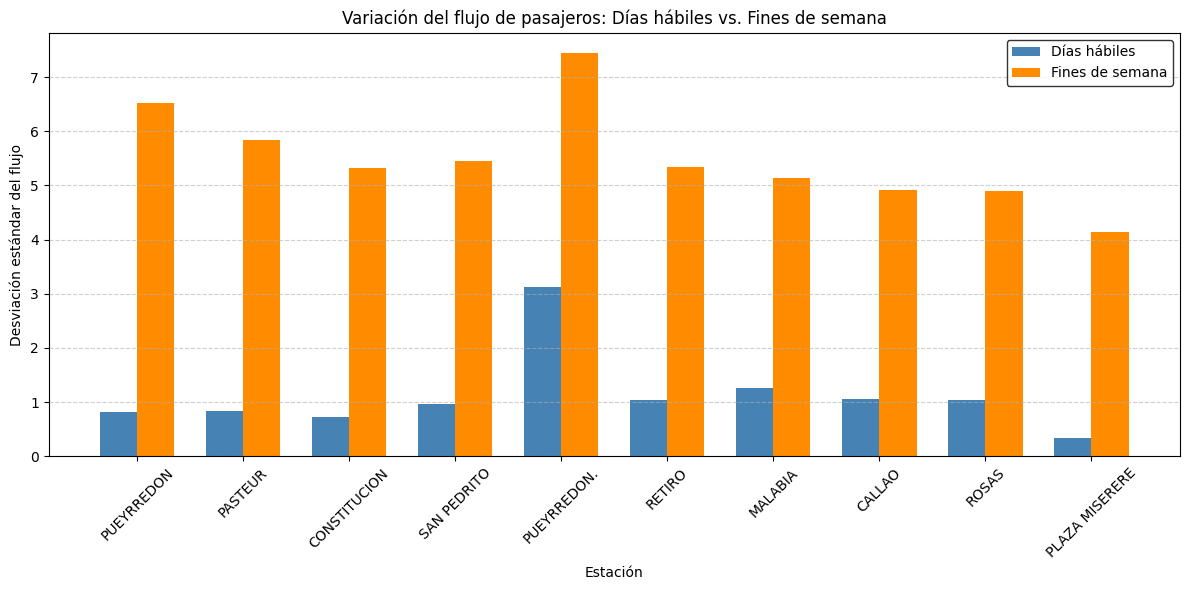

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionamos las 10 estaciones con mayor diferencia de variación
top_estaciones = df_comparacion.sort_values(by='DIFERENCIA', ascending=False).head(10)

# Posiciones para las barras
x = np.arange(len(top_estaciones['ESTACION']))  # etiquetas de estaciones
width = 0.35  # ancho de las barras

# Crear figura
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, top_estaciones['VAR_HABIL'], width, label='Días hábiles', color='steelblue')
plt.bar(x + width/2, top_estaciones['VAR_FIN_SEMANA'], width, label='Fines de semana', color='darkorange')

# Etiquetas y títulos
plt.xlabel('Estación')
plt.ylabel('Desviación estándar del flujo')
plt.title('Variación del flujo de pasajeros: Días hábiles vs. Fines de semana')
plt.xticks(x, top_estaciones['ESTACION'], rotation=45)
plt.legend(labelcolor='black', facecolor='white', edgecolor='black')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Mostrar gráfico
plt.show()